# Government Expenditure Fraud Detection System (Isolation Forest)

This notebook transitions from rule-based SQL analysis to **upsupervised anomaly detection**. While SQL captures known patterns, machine learning allows us to identify complex, multi-dimensional outliers that might bypass traditional audits.

- **Goal**: Identify irregular expenditure patterns without pre-defined labels using the **Isolation Forest** algorithm.
- **Data Labeling**: Generate anomaly labels to serve as ground truth for future predictive modeling **(XGBoost)**.

### 1. Import Libraries & Data Loading
We load the public expenditure dataset previously analyzed in **SQL**. In this step, we verify data integrity and prepare the core structure for the AI model to process.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [2]:
# Define paths
from pathlib import Path
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "02_data"
OUTPUT_PATH = BASE_DIR / "03_outputs"
MODEL_PATH = BASE_DIR / "06_models"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the dataset (CSV exported from DBeaver)
FILE_PATH = os.path.join(DATA_PATH, 'expenditure_data.csv')
df = pd.read_csv(FILE_PATH)

print(f"Total Records Loaded: {len(df)}")
df.head()

Total Records Loaded: 10014


,tx_id,exp_date,dept_id,vendor_name,amount,description
0,1,2020-05-10,7,Vendor_61,11006.71,Standard operational expense
1,2,2022-06-27,2,Vendor_75,2424.32,Standard operational expense
2,3,2022-01-22,8,Vendor_24,5072.26,Standard operational expense
3,4,2018-11-06,6,Vendor_88,5643.18,Emergency Year-end Fund Utilization
4,5,2022-12-21,6,Vendor_64,19583.10,Emergency Year-end Fund Utilization


### 2. Feature Engineering
AI models cannot directly interpret date strings. We extract the **'Month'** from the expenditure date to create a numerical feature. We select **Amount, Month, and Department ID** as the primary features for anomaly detection.

In [4]:
# Convert date to datetime and extract Month
df['exp_date'] = pd.to_datetime(df['exp_date'])
df['month'] = df['exp_date'].dt.month

# Feature Selection
features = ['amount', 'month', 'dept_id']
X = df[features]

print("Selected Features for Modeling:")
print(features)

Selected Features for Modeling:
['amount', 'month', 'dept_id']


### 3. Model Training (Unsupervised Learning : Isolation Forest)
We utilize the **Isolation Forest** algorithm to detect anomalies. This model measures how easily a data point can be isolated; outliers are separated much faster than normal points. We set `contamination=0.02` to target the top 2% of records as potential fraud.

In [5]:
# Initialize Isolation Forest
# n_estimators: Number of trees
# contamination: Expected ratio of anomalies (2%)
model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)

# Fit and Predict (-1: Anomaly, 1: Normal)
df['anomaly_score'] = model.fit_predict(X)
df['anomaly_status'] = df['anomaly_score'].map({-1: 'Anomaly', 1: 'Normal'})

# Check counts
anomaly_counts = df['anomaly_status'].value_counts()
print("Detection Results:")
print(anomaly_counts)

Detection Results:
anomaly_status
Normal     9813
Anomaly     201
Name: count, dtype: int64


### 4. Visualization
We visualize the results to inspect which data points the AI flagged. **Red points (Anomaly)** represent high-value transactions or irregular timing that deviate from standard spending patterns.

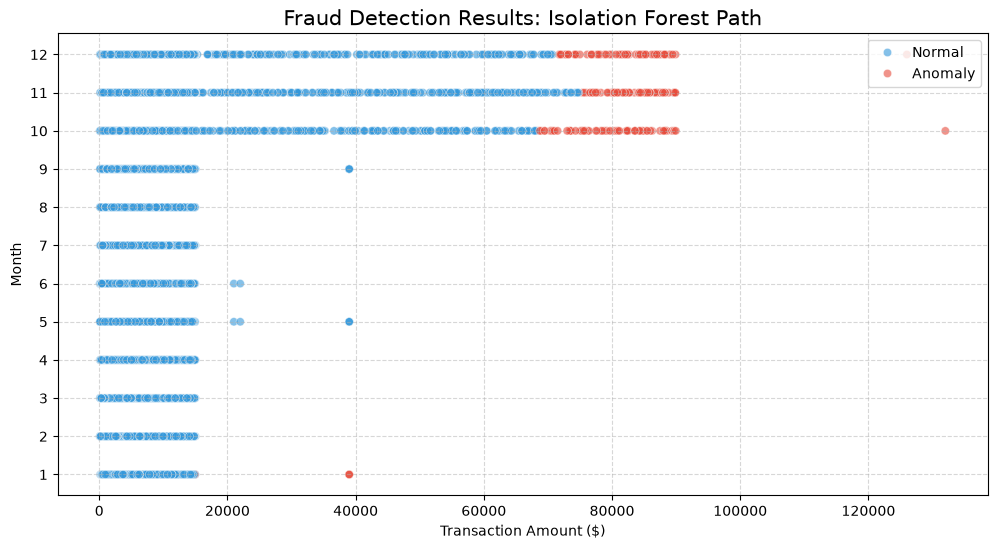

In [6]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='amount', 
    y='month', 
    hue='anomaly_status', 
    palette={'Anomaly': '#e74c3c', 'Normal': '#3498db'},
    alpha=0.6
)

plt.title('Fraud Detection Results: Isolation Forest Path', fontsize=15)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Month')
plt.yticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

### 5. Result Export (Bridge to XGBoost)
We save the dataset including the 'Anomaly Labels' generated via unsupervised learning. This file will serve as the training data for **XGBoost (Supervised Learning)** session to enhance predictive accuracy.

In [7]:
# Save for Supervised Learning(XGBoost)
FILE_PATH = os.path.join(DATA_PATH, 'labeled_expenditure_data.csv')
df.to_csv(FILE_PATH, index=False)

print(f"✅ Complete. Result saved to: {FILE_PATH}")
print(f"📊 Final Shape: {df.shape}")

✅ Complete. Result saved to: C:\Users\tjrdu\OneDrive\Desktop\GitHub\Financial-Risk-Decision-Intelligence-System\02_data\labeled_expenditure_data.csv
📊 Final Shape: (10014, 9)
